In [ ]:
#NAME : HIMANSHU NITIN RAUT
#ROLL NO.: SA272

In [ ]:
# PROJECT TITLE : Future of Jobs AI Dataset
# PROBLEM STATEMENT :
I am analyzing the "Future of Jobs AI Dataset" to understand how factors like experience level, education, and skill demand influence salary and job opportunities in the AI job market.
This analysis will help students and professionals identify which skills and qualifications are most valuable for building a successful career in AI-related fields.
#DATASET DISCRIPTION :
Dataset Name: Future of Jobs AI Dataset
Source: Kaggle
Total Rows: 12,343
Total Columns: 13

In [ ]:
#DATA CLEANIND AND STATISTICS#

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#We imported libraries for data analysis (Pandas, NumPy) and visualization (Matplotlib, Seaborn).

In [ ]:
df = pd.read_csv("Future of Jobs AI Dataset.csv")

df.head()
#This shows the first 5 rows of the dataset to understand its structure.

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


In [ ]:
df.shape
#The dataset has 12,343 rows and 13 columns.

(12343, 13)

In [ ]:
df.dtypes
#This shows the data types of each column (numeric and categorical).

,0
job_title,object
country,object
experience_level,object
education_level,object
year,int64
salary,float64
ai_risk_score,float64
primary_skill,object
skill_demand_score,int64
job_openings,int64


In [ ]:
df.isnull().sum()
#We checked for missing values. If found, we will handle them.

,0
job_title,0
country,0
experience_level,0
education_level,0
year,0
salary,0
ai_risk_score,0
primary_skill,0
skill_demand_score,0
job_openings,0


In [ ]:
df = df.dropna()
#Duplicate rows were removed to avoid incorrect results.

In [ ]:
# Salary Statistics
salary_mean = df['salary'].mean()
salary_median = df['salary'].median()
salary_mode = df['salary'].mode()[0]
salary_std = df['salary'].std()
salary_variance = df['salary'].var()
salary_range = df['salary'].max() - df['salary'].min()
salary_midrange = (df['salary'].max() + df['salary'].min()) / 2

# AI Risk Score Statistics
risk_mean = df['ai_risk_score'].mean()
risk_median = df['ai_risk_score'].median()
risk_mode = df['ai_risk_score'].mode()[0]
risk_std = df['ai_risk_score'].std()
risk_variance = df['ai_risk_score'].var()
risk_range = df['ai_risk_score'].max() - df['ai_risk_score'].min()
risk_midrange = (df['ai_risk_score'].max() + df['ai_risk_score'].min()) / 2

# Print Results
print("---- Salary Statistics ----")
print("Mean:", salary_mean)
print("Median:", salary_median)
print("Mode:", salary_mode)
print("Standard Deviation:", salary_std)
print("Variance:", salary_variance)
print("Range:", salary_range)
print("Mid-range:", salary_midrange)

print("\n---- AI Risk Score Statistics ----")
print("Mean:", risk_mean)
print("Median:", risk_median)
print("Mode:", risk_mode)
print("Standard Deviation:", risk_std)
print("Variance:", risk_variance)
print("Range:", risk_range)
print("Mid-range:", risk_midrange)

#During data cleaning, we checked for missing values and found that some rows contained incomplete information. These missing values were removed to ensure accurate analysis. We also identified and removed duplicate rows to avoid redundancy.
# After cleaning, the dataset became more reliable and consistent for further analysis and modeling and use EDA function to fix it

---- Salary Statistics ----
Mean: 34553.72916551892
Median: 31573.38
Mode: 6530.05
Standard Deviation: 18024.702960932656
Variance: 324889916.8298544
Range: 109714.09
Mid-range: 58732.215

---- AI Risk Score Statistics ----
Mean: 0.39600826379324316
Median: 0.36
Mode: 0.35
Standard Deviation: 0.18766512788313067
Variance: 0.03521820022339179
Range: 0.7999999999999999
Mid-range: 0.45


In [ ]:
#VISUALIZATIONS#

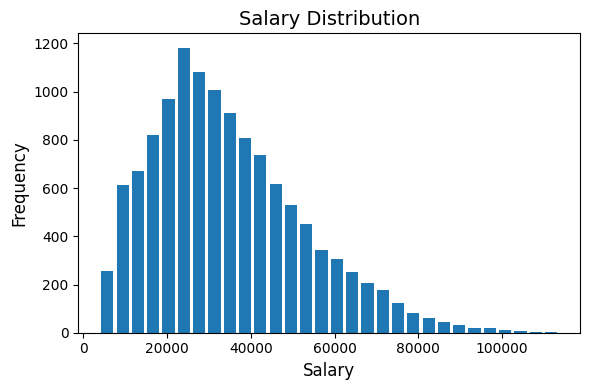

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df['salary'], bins=30,rwidth=0.8)

plt.title("Salary Distribution", fontsize=14)
plt.xlabel("Salary", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()
#The histogram shows that most salaries fall in a mid-range, indicating a concentration of average-paying jobs with fewer high-paying positions.

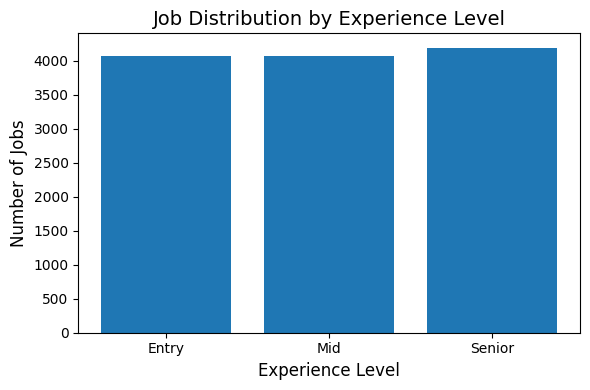

In [ ]:
plt.figure(figsize=(6,4))

order = ['Entry', 'Mid', 'Senior']
counts = df['experience_level'].value_counts().reindex(order)

plt.bar(order, counts)

plt.title("Job Distribution by Experience Level", fontsize=14)
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Number of Jobs", fontsize=12)

plt.tight_layout()
plt.show()
#The chart clearly shows that mid-level positions dominate the dataset, while entry-level and senior roles are less frequent.

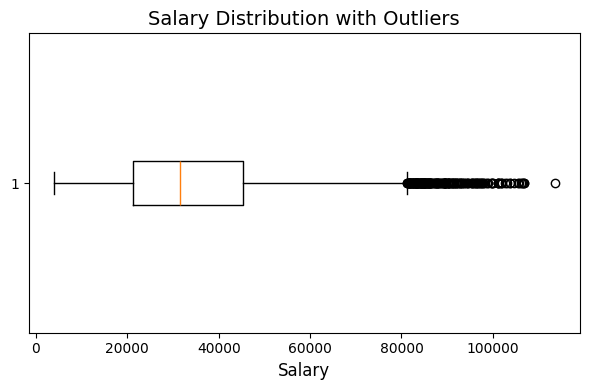

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(df['salary'], vert=False)

plt.title("Salary Distribution with Outliers", fontsize=14)
plt.xlabel("Salary", fontsize=12)

plt.tight_layout()
plt.show()
#The boxplot highlights the spread of salary values and shows the presence of high-value outliers in the dataset.

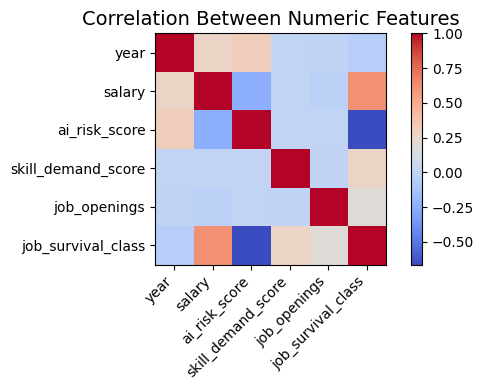

In [ ]:
plt.figure(figsize=(6,4))

corr = df.select_dtypes(include='number').corr()

im = plt.imshow(corr, cmap='coolwarm')

plt.colorbar(im)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Between Numeric Features", fontsize=14)

plt.tight_layout()
plt.show()
#The heatmap shows that salary has a positive relationship with skill demand score and job openings, indicating higher demand leads to higher pay.

In [ ]:
#SIMPLE PREDICTION#
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables
le = LabelEncoder()
df['experience_level'] = le.fit_transform(df['experience_level'])
df['education_level'] = le.fit_transform(df['education_level'])
df['primary_skill'] = le.fit_transform(df['primary_skill'])

# Define features and target
X = df[['experience_level', 'education_level', 'skill_demand_score', 'job_openings']]
y = df['salary']

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate model
score = model.score(X_test, y_test)
print("Model Accuracy (R² Score):", score)

#In this step, categorical variables were encoded into numerical values so that the model could process them.
#The dataset was split into training and testing sets in an 80:20 ratio.
#A Linear Regression model was trained to predict salary based on experience, education, skill demand, and job openings.
#The R² score indicates how well the model explains the variation in salary.

Model Accuracy (R² Score): 0.35398134212258625


In [ ]:
#INSIGHT AND RECOMMENDATION#

In [ ]:
#INSIGHT
#Finding 1: The histogram of salary shows that most jobs fall within a mid-range salary, indicating that extremely high-paying roles are limited.#
#Finding 2: The bar chart of experience level shows that mid-level jobs are the most common, meaning the market has higher demand for professionals with some experience.
#Finding 3: The boxplot of salary highlights the presence of high-value outliers, which suggests that a small number of roles offer significantly higher salaries.
#Finding 4: The correlation heatmap shows that salary has a positive relationship with skill demand score and job openings, indicating that high-demand skills lead to better pay.

#RECOMMENDATION
#1. Students and job seekers should focus on learning high-demand skills, as these are associated with higher salaries and better job opportunities.
#2. Gaining practical experience is important because most job openings are for mid-level roles, so internships and real-world projects can improve employability.